# Final k-NN Comparison

This notebook compares three k-nearest-neighbors approaches on the VGG-16 block4 pool features.

W&B is intentionally left out. Each approach prints its own metrics and shows its own normalized confusion matrix.


In [1]:
from pathlib import Path
import json
import wandb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
CONFIG = {
    "n_neighbors": 5,
    "batch_size": 64,
    "test_size": 0.20,
    "random_state": 42,
}


In [3]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "extracted_features_alena").exists():
            return path
    raise FileNotFoundError(
        "Could not find data/extracted_features_alena from the current working directory."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "extracted_features_alena"
print(f"Project root: {PROJECT_ROOT}")
print(f"Feature directory: {DATA_DIR}")

X = np.load(DATA_DIR / "features_block4pool.npy")
y = np.load(DATA_DIR / "labels_block4pool.npy")

with open(DATA_DIR / "class_indices.json", "r", encoding="utf-8") as f:
    class_to_idx = json.load(f)

idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
class_names = [idx_to_class[idx] for idx in sorted(idx_to_class)]
n_classes = len(class_names)

print(f"Features: {X.shape}")
print(f"Labels: {y.shape}")
print(f"Classes: {n_classes}")


Project root: C:\Users\marti\Documents\GitHub\odysseus
Feature directory: C:\Users\marti\Documents\GitHub\odysseus\data\extracted_features_alena
Features: (55329, 512)
Labels: (55329,)
Classes: 24


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


Train: (44263, 512), Test: (11066, 512)


## Helper functions

The helper functions keep the comparison fair: every approach uses the same train/test split, the same `k`, and the same evaluation code.


In [5]:
def _as_float_tensor(array):
    return torch.from_numpy(array.astype(np.float32, copy=False))


def _majority_vote(nn_labels, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, labels in enumerate(nn_labels):
        counts = torch.bincount(labels.long(), minlength=n_classes)
        y_pred[row_idx] = int(counts.argmax())
    return y_pred


def _weighted_vote(nn_labels, weights, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, (labels, row_weights) in enumerate(zip(nn_labels, weights)):
        scores = torch.zeros(n_classes, dtype=torch.float64)
        scores.scatter_add_(0, labels.long(), row_weights.double())
        y_pred[row_idx] = int(scores.argmax())
    return y_pred


def predict_knn_euclidean(X_train, y_train, X_test, n_classes, k=5, batch_size=64, weighted=False):
    train = _as_float_tensor(X_train)
    test = _as_float_tensor(X_test)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    train_norm = (train * train).sum(dim=1)
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        dists_sq = (batch * batch).sum(dim=1, keepdim=True) + train_norm[None, :] - 2 * batch.matmul(train_t)
        nn_dists_sq, nn_idx = torch.topk(dists_sq, k=k, largest=False, dim=1)
        nn_labels = y_train_t[nn_idx]

        if weighted:
            weights = 1 / (torch.sqrt(torch.clamp(nn_dists_sq, min=0)) + 1e-12)
            batch_pred = _weighted_vote(nn_labels, weights, n_classes)
        else:
            batch_pred = _majority_vote(nn_labels, n_classes)

        y_pred[start_idx:end_idx] = batch_pred
        if end_idx == len(test) or end_idx % (batch_size * 10) == 0:
            print(f"Predicted {end_idx}/{len(test)}")

    return y_pred


def predict_knn_cosine_weighted(X_train, y_train, X_test, n_classes, k=5, batch_size=64):
    train = torch.nn.functional.normalize(_as_float_tensor(X_train), p=2, dim=1)
    test = torch.nn.functional.normalize(_as_float_tensor(X_test), p=2, dim=1)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        similarities = batch.matmul(train_t)
        nn_similarities, nn_idx = torch.topk(similarities, k=k, largest=True, dim=1)
        nn_labels = y_train_t[nn_idx]
        cosine_distances = 1 - nn_similarities
        weights = 1 / (torch.clamp(cosine_distances, min=0) + 1e-12)
        y_pred[start_idx:end_idx] = _weighted_vote(nn_labels, weights, n_classes)

        if end_idx == len(test) or end_idx % (batch_size * 10) == 0:
            print(f"Predicted {end_idx}/{len(test)}")

    return y_pred


def evaluate_approach(name, y_true, y_pred):
    metrics = {
        "approach": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    print(f"Results for {name}")
    print(f"Accuracy:    {metrics['accuracy']:.4f}")
    print(f"Macro-F1:    {metrics['macro_f1']:.4f}")
    print(f"Weighted-F1: {metrics['weighted_f1']:.4f}")
    print()
    print("Classification report per class:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return metrics


def plot_confusion_matrix(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(idx_to_class), normalize="true")

    plt.figure(figsize=(16, 14))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        cbar=True,
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"size": 7},
    )
    plt.title(f"Normalized Confusion Matrix - {name}")
    plt.xlabel("Predicted Letter")
    plt.ylabel("True Letter")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("knn_confusion_matrix.png", dpi=300)
    plt.show()



## Approach 1: Euclidean majority KNN

This is the simplest KNN variant. The model finds the `k` nearest samples using Euclidean distance. Every neighbor has exactly one vote.


Predicted 640/11066
Predicted 1280/11066
Predicted 1920/11066
Predicted 2560/11066
Predicted 3200/11066
Predicted 3840/11066
Predicted 4480/11066
Predicted 5120/11066
Predicted 5760/11066
Predicted 6400/11066
Predicted 7040/11066
Predicted 7680/11066
Predicted 8320/11066
Predicted 8960/11066
Predicted 9600/11066
Predicted 10240/11066
Predicted 10880/11066
Predicted 11066/11066
Results for Euclidean majority KNN
Accuracy:    0.5405
Macro-F1:    0.4748
Weighted-F1: 0.5349

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.4203    0.7105    0.5282      1043
        Beta     0.2667    0.3659    0.3085       164
         Chi     0.4212    0.5116    0.4620       303
       Delta     0.5744    0.5133    0.5421       376
     Epsilon     0.4600    0.6531    0.5398       784
         Eta     0.4139    0.5921    0.4872       532
       Gamma     0.3402    0.1988    0.2510       166
        Iota     0.5632    0.4942    0.5264       433
    

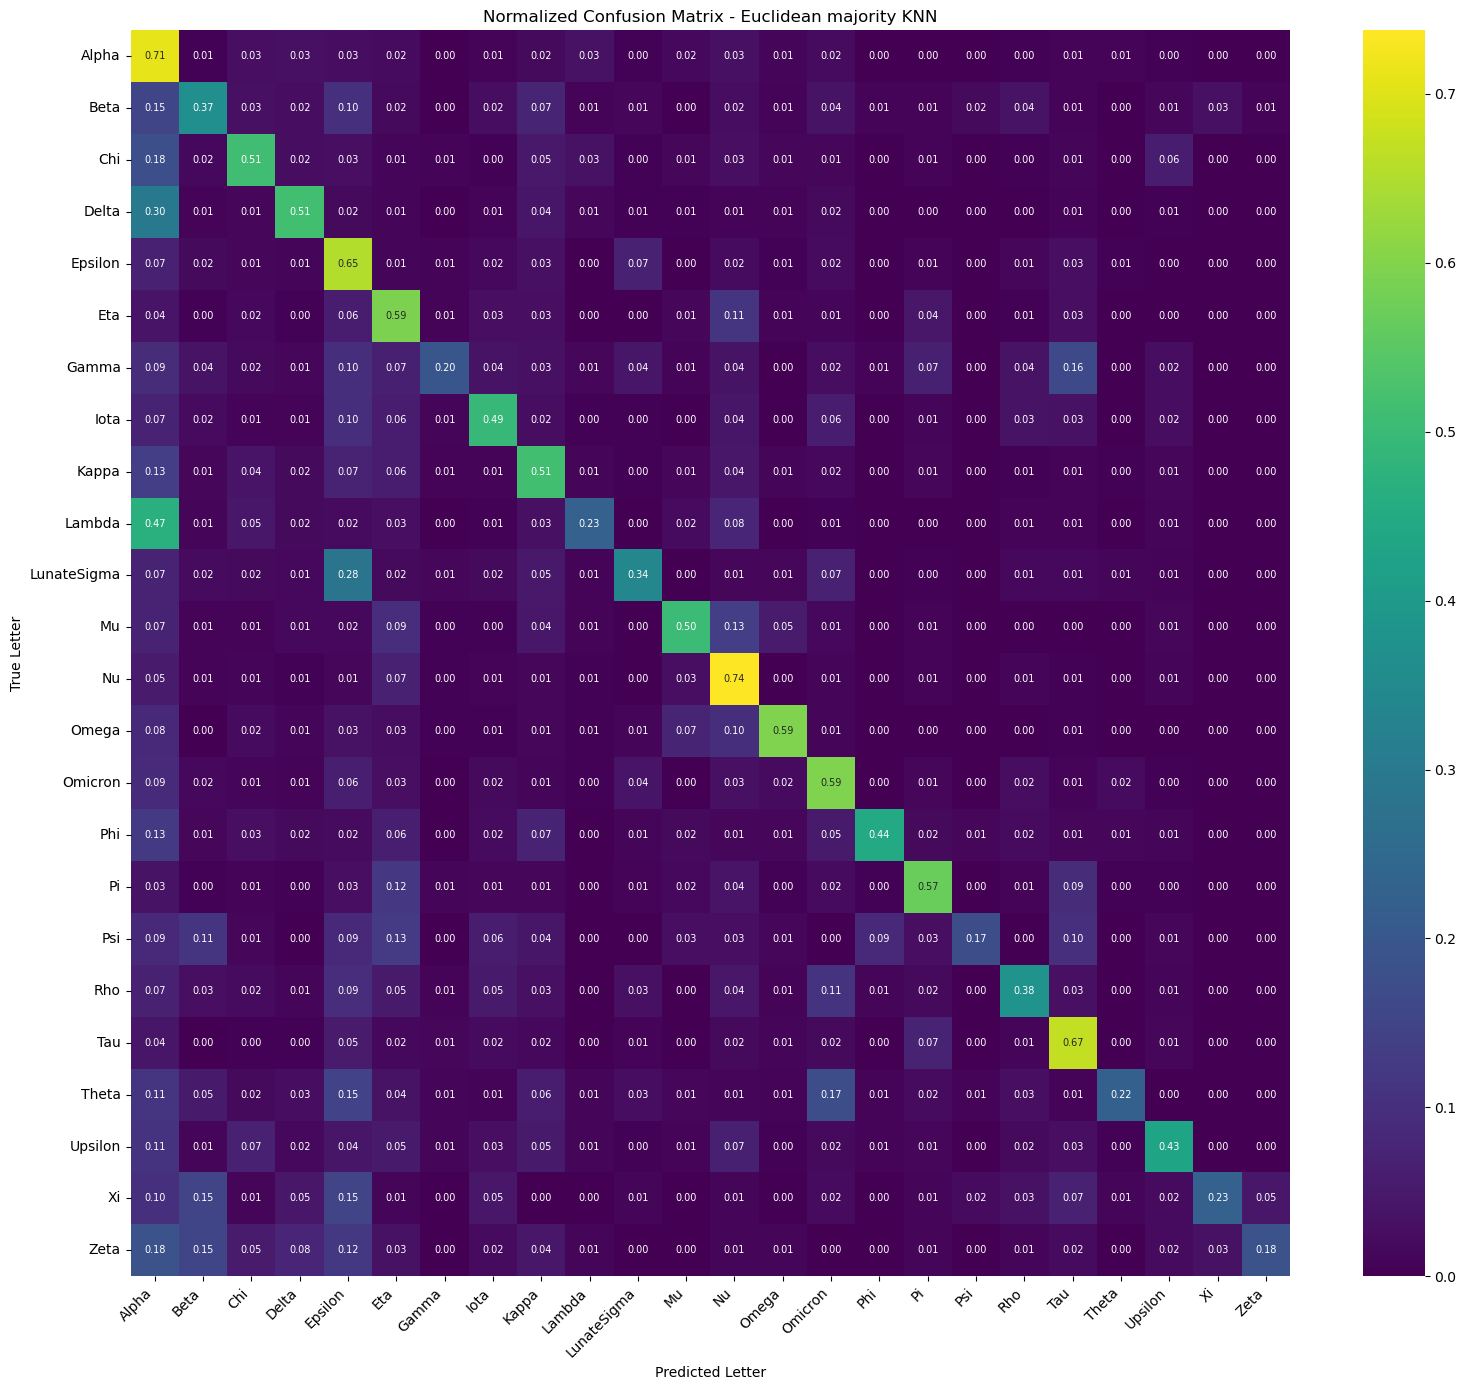

In [6]:
y_pred_euclidean_majority = predict_knn_euclidean(
    X_train_scaled,
    y_train,
    X_test_scaled,
    n_classes=n_classes,
    k=CONFIG["n_neighbors"],
    batch_size=CONFIG["batch_size"],
    weighted=False,
)

metrics_euclidean_majority = evaluate_approach(
    "Euclidean majority KNN",
    y_test,
    y_pred_euclidean_majority,
)
plot_confusion_matrix("Euclidean majority KNN", y_test, y_pred_euclidean_majority)


## Approach 2: Euclidean distance-weighted KNN

This variant also uses Euclidean distance, but closer neighbors receive stronger voting weights. A very close neighbor can therefore matter more than a farther neighbor.


In [ ]:
y_pred_euclidean_weighted = predict_knn_euclidean(
    X_train_scaled,
    y_train,
    X_test_scaled,
    n_classes=n_classes,
    k=CONFIG["n_neighbors"],
    batch_size=CONFIG["batch_size"],
    weighted=True,
)

metrics_euclidean_weighted = evaluate_approach(
    "Euclidean distance-weighted KNN",
    y_test,
    y_pred_euclidean_weighted,
)
plot_confusion_matrix("Euclidean distance-weighted KNN", y_test, y_pred_euclidean_weighted)


Predicted 640/11066
Predicted 1280/11066
Predicted 1920/11066
Predicted 2560/11066
Predicted 3200/11066
Predicted 3840/11066
Predicted 4480/11066
Predicted 5120/11066
Predicted 5760/11066
Predicted 6400/11066
Predicted 7040/11066
Predicted 7680/11066


## Approach 3: Cosine distance-weighted KNN

This variant compares the direction of the feature vectors instead of their absolute Euclidean distance. This can be useful for neural-network features, where the activation pattern can matter more than vector magnitude.


In [ ]:
y_pred_cosine_weighted = predict_knn_cosine_weighted(
    X_train_scaled,
    y_train,
    X_test_scaled,
    n_classes=n_classes,
    k=CONFIG["n_neighbors"],
    batch_size=CONFIG["batch_size"],
)

metrics_cosine_weighted = evaluate_approach(
    "Cosine distance-weighted KNN",
    y_test,
    y_pred_cosine_weighted,
)
plot_confusion_matrix("Cosine distance-weighted KNN", y_test, y_pred_cosine_weighted)


## Final comparison

Macro-F1 is a useful main metric here because it gives every class equal importance. Accuracy and weighted-F1 can be influenced more strongly by frequent classes.


In [ ]:
results_df = pd.DataFrame([
    metrics_euclidean_majority,
    metrics_euclidean_weighted,
    metrics_cosine_weighted,
]).sort_values("macro_f1", ascending=False).reset_index(drop=True)

results_df


In [ ]:
best = results_df.iloc[0]
print("Best approach by Macro-F1:")
print(f"Approach:    {best['approach']}")
print(f"Accuracy:    {best['accuracy']:.4f}")
print(f"Macro-F1:    {best['macro_f1']:.4f}")
print(f"Weighted-F1: {best['weighted_f1']:.4f}")
